In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
import torchvision
from torch.utils.tensorboard import SummaryWriter

: 

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")


Using device: cuda


In [4]:
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="simbaswe/galah4", filename="labels.npy", repo_type="dataset", local_dir=".")
hf_hub_download(repo_id="simbaswe/galah4", filename="spectra.npy", repo_type="dataset", local_dir=".")

   ---------------------------------------- 0.0/625.2 kB ? eta -:--:--
   ---------------------------------------- 625.2/625.2 kB 36.1 MB/s  0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------------------------- 3.7/3.7 MB 86.0 MB/s  0:00:00

   ----------------------------------------  0/10 [tqdm]
   ----------------------------------------  0/10 [tqdm]
   -------- -------------------------------  2/10 [mdurl]
   ---------------- -----------------------  4/10 [click]
   ---------------- -----------------------  4/10 [click]
   ------------------------ ---------------  6/10 [markdown-it-py]
   ------------------------ ---------------  6/10 [markdown-it-py]
   ------------------------ ---------------  6/10 [markdown-it-py]
   ------------------------ ---------------  6/10 [markdown-it-py]
   ------------------------ ---------------  6/10 [markdown-it-py]
   ---------------------------- -----------  7/10 [rich]
   ------------------------

labels.npy:   0%|          | 0.00/285k [00:00<?, ?B/s]

spectra.npy:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

'spectra.npy'

In [3]:
import os

data_dir = r"C:\Users\J Birbou\ML_Class\HW1"
spectra = np.load(os.path.join(data_dir, "spectra.npy"))
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(os.path.join(data_dir, "labels.npy"))
# We only use the three labels: t_eff, log_g, fe_h
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]
spectra = np.log(np.maximum(spectra, 0.2))

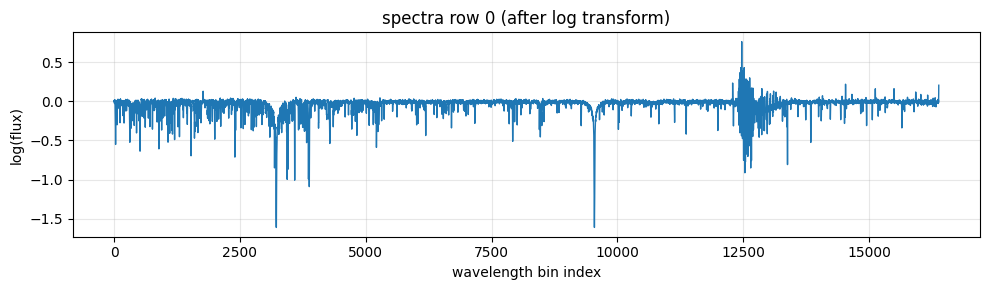

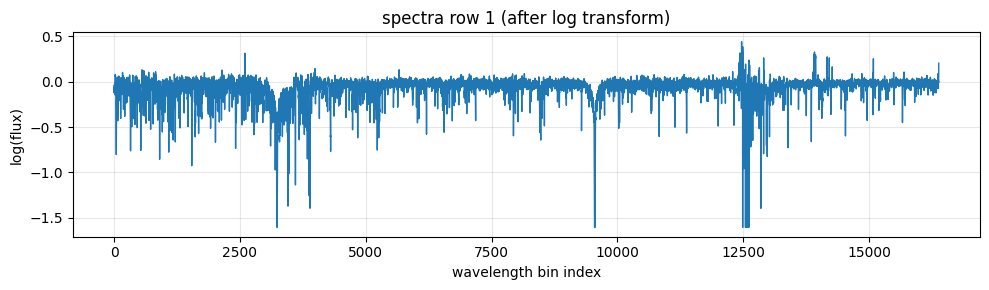

In [12]:
import matplotlib.pyplot as plt

for i in range(2):  # first 2 rows
    plt.figure(figsize=(10, 3))
    plt.plot(spectra[i], lw=1)
    plt.title(f"spectra row {i} (after log transform)")
    plt.xlabel("wavelength bin index")
    plt.ylabel("log(flux)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [4]:
print(f"Using device: {device}")

# Z-score normalize labels
labels_mean = labels.mean(axis=0)
labels_std = labels.std(axis=0)
labels = (labels - labels_mean) / labels_std

# Z-score normalize spectra
spectra_mean = spectra.mean(axis=0)
spectra_std = spectra.std(axis=0)
spectra = (spectra - spectra_mean) / spectra_std

# Convert to tensors
spectra_tensor = torch.from_numpy(spectra).float()
labels_tensor = torch.from_numpy(labels).float()

print(f"spectra_tensor dtype: {spectra_tensor.dtype}, shape: {spectra_tensor.shape}")
print(f"labels_tensor dtype: {labels_tensor.dtype}, shape: {labels_tensor.shape}")

# Move to device
spectra_tensor = spectra_tensor.to(device)
labels_tensor = labels_tensor.to(device)

print(f"spectra_tensor device: {spectra_tensor.device}")
print(f"labels_tensor device: {labels_tensor.device}")





Using device: cuda
spectra_tensor dtype: torch.float32, shape: torch.Size([8914, 16384])
labels_tensor dtype: torch.float32, shape: torch.Size([8914, 3])
spectra_tensor device: cuda:0
labels_tensor device: cuda:0


In [5]:
# Split data
num_samples = spectra_tensor.shape[0]
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size

# Use TensorDataset to create a dataset
train_dataset, val_dataset, test_dataset \
= random_split(TensorDataset(spectra_tensor, labels_tensor), [train_size, val_size, test_size])

# Create DataLoaders
batch_size = 64  # increased from 10 for better GPU utilization
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 6239, Val: 1337, Test: 1338


In [7]:
# Define neural network as a class
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.layer1 = nn.Linear(16384, 128)  # Input: 16384 spectra features
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(128, 128)  # Hidden layer
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(128, 3)  # Output: 3 labels (t_eff, log_g, fe_h)

    def forward(self, x):
        x = self.relu1(self.layer1(x))  # First hidden layer
        hidden = self.relu2(self.layer2(x))  # Second hidden layer (embedding space)
        output = self.layer3(hidden)  # Final regression output
        return output  # Return predictions for 3 targets

In [8]:
# Initialize the model
model = SimpleNN().to(device)
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Lower LR for stability

# Define writer for TensorBoard logging
writer = SummaryWriter("runs/spectra_regression")

# Log the network architecture
dummy_input = torch.randn(1, 16384).to(device)  # Match input shape (batch=1, features=4096)
writer.add_graph(model, dummy_input)

print(f"Model: {model}")
print(f"Parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Device: {next(model.parameters()).device}")

Model: SimpleNN(
  (layer1): Linear(in_features=16384, out_features=128, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=128, out_features=128, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=128, out_features=3, bias=True)
)
Parameters: 2114179
Device: cuda:0


In [9]:
# Train the model
num_epochs = 500  # Reduced from 500 for faster iteration
train_losses, val_losses = [], []

for epoch in range(num_epochs):  # loop through every epoch
    # Training
    model.train()  # The model should be in training mode
    train_loss = 0
    for batch_x, batch_y in train_loader:  # loop through every batch
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)  # Ensure on device

        optimizer.zero_grad()  # set the gradients to zero
        predictions = model(batch_x)  # make a prediction with the current model
        loss = criterion(predictions, batch_y)  # calculate the loss
        loss.backward()  # calculate the gradients
        optimizer.step()  # updates the weights and biases
        train_loss += loss.item()  # accumulate loss per batch
    train_loss /= len(train_loader)  # average loss per epoch
    train_losses.append(train_loss)

    writer.add_scalar("train_loss", train_loss, epoch)

    # Validation
    model.eval()  # The model should be in eval mode
    val_loss = 0
    with torch.no_grad():  # no gradients for validation
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item()
    val_loss /= len(val_loader)  # average loss per epoch
    val_losses.append(val_loss)

    writer.add_scalar("val_loss", val_loss, epoch)

    # Log weight histograms
    for name, param in model.named_parameters():
        writer.add_histogram(name, param, epoch)

    # Print progress
    if epoch % 10 == 0:  # More frequent logging
        print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

writer.close()  # Close TensorBoard writer
print("Training complete!")

Epoch 0: Train Loss = 0.5030, Val Loss = 0.1986
Epoch 10: Train Loss = 4.2602, Val Loss = 0.6543
Epoch 20: Train Loss = 0.0435, Val Loss = 0.0776
Epoch 30: Train Loss = 0.0265, Val Loss = 0.0727
Epoch 40: Train Loss = 0.0162, Val Loss = 0.0734
Epoch 50: Train Loss = 0.0239, Val Loss = 0.0999
Epoch 60: Train Loss = 0.0109, Val Loss = 0.0652
Epoch 70: Train Loss = 0.0097, Val Loss = 0.0671
Epoch 80: Train Loss = 0.0099, Val Loss = 0.0644
Epoch 90: Train Loss = 0.0066, Val Loss = 0.0649
Epoch 100: Train Loss = 0.0105, Val Loss = 0.0638
Epoch 110: Train Loss = 0.0051, Val Loss = 0.0617
Epoch 120: Train Loss = 0.0068, Val Loss = 0.0606
Epoch 130: Train Loss = 0.0181, Val Loss = 0.0661
Epoch 140: Train Loss = 0.0053, Val Loss = 0.0582
Epoch 150: Train Loss = 0.0063, Val Loss = 0.0589
Epoch 160: Train Loss = 0.0038, Val Loss = 0.0581
Epoch 170: Train Loss = 0.0053, Val Loss = 0.0592
Epoch 180: Train Loss = 0.0028, Val Loss = 0.0587
Epoch 190: Train Loss = 0.0036, Val Loss = 0.0608
Epoch 200: 

In [10]:
# Test the model
model.eval()  # Set to eval mode
test_loss = 0
all_predictions = []
all_targets = []

with torch.no_grad():  # No gradients for testing
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        test_loss += loss.item()

        # Collect for metrics
        all_predictions.append(predictions.cpu())
        all_targets.append(batch_y.cpu())

test_loss /= len(test_loader)
all_predictions = torch.cat(all_predictions)
all_targets = torch.cat(all_targets)

# Additional metrics
mae = torch.mean(torch.abs(all_predictions - all_targets)).item()
print(f"Final Test Loss (MSE): {test_loss:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Predictions shape: {all_predictions.shape}, Targets shape: {all_targets.shape}")

Final Test Loss (MSE): 0.0683
Mean Absolute Error: 0.1791
Predictions shape: torch.Size([1338, 3]), Targets shape: torch.Size([1338, 3])


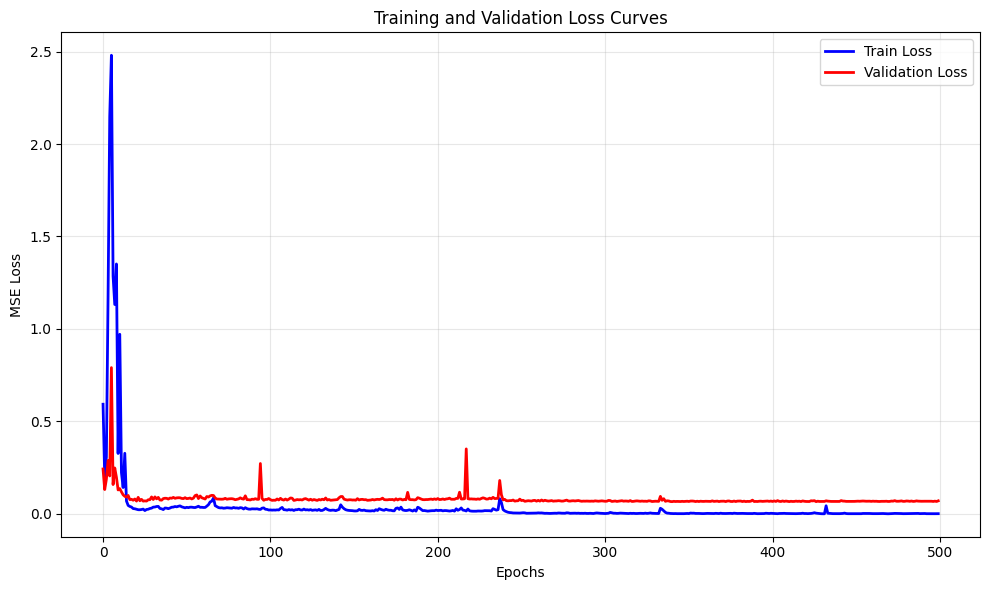

In [36]:
# Plot training/validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss", color="blue", linewidth=2)
plt.plot(val_losses, label="Validation Loss", color="red", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

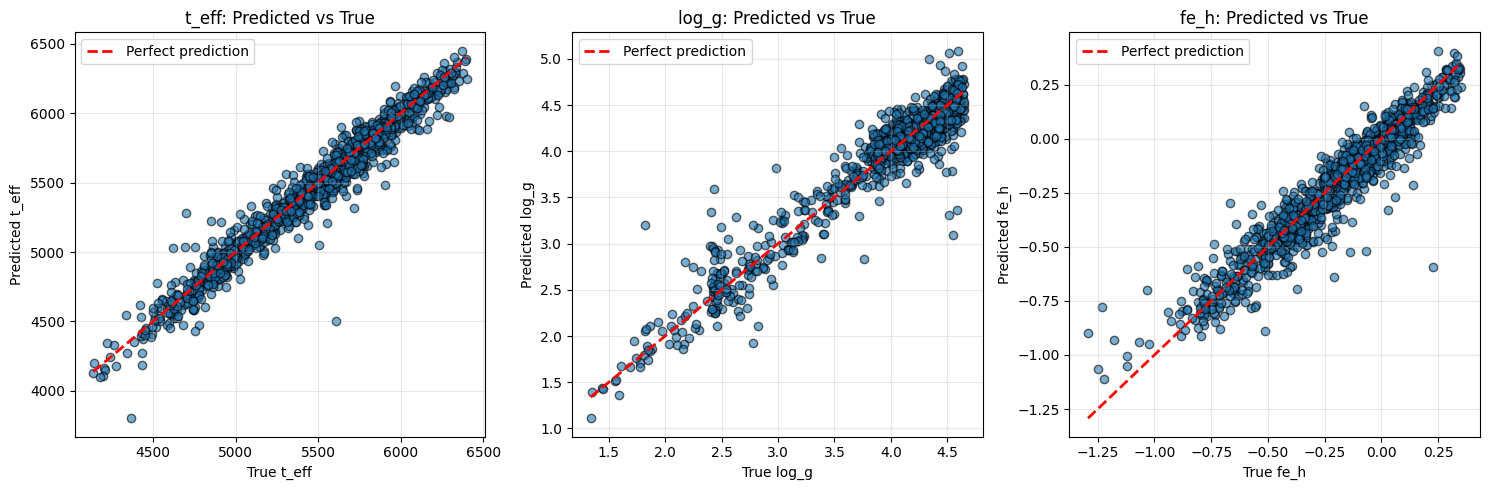

t_eff correlation: 0.9791
log_g correlation: 0.9595
fe_h correlation: 0.9563


In [ ]:
# Final visualization: Predicted vs True labels (denormalized)
# Denormalize predictions and targets
pred_denorm = all_predictions.numpy() * labels_std + labels_mean
true_denorm = all_targets.numpy() * labels_std + labels_mean

# Plot for each label
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
label_names = ["t_eff", "log_g", "fe_h"]

for i, (name, ax) in enumerate(zip(label_names, axes)):
    ax.scatter(true_denorm[:, i], pred_denorm[:, i], alpha=0.6, edgecolors='k')
    ax.plot([true_denorm[:, i].min(), true_denorm[:, i].max()],
            [true_denorm[:, i].min(), true_denorm[:, i].max()],
            'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name}: Predicted vs True')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print correlation coefficients
for i, name in enumerate(label_names):
    corr = np.corrcoef(true_denorm[:, i], pred_denorm[:, i])[0, 1]
    print(f"{name} correlation: {corr:.4f}")
